# **Challenge telecomx 2**

##Preparacion de los datos

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [3]:
from google.colab import files
files.upload()

Saving datos_tratados.csv to datos_tratados.csv


{'datos_tratados.csv': b'customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias\n0002-ORFBO,0,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3,2.1866666666666665\n0003-MKNFE,0,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4,1.9966666666666666\n0004-TLHLJ,1,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.4633333333333334\n0011-IGKFF,1,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.2666666666666666\n0013-EXCHZ,1,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4,2.796666666666667\n0013-MHZWF,0,Female,0,No,Yes,9,Yes,No,DSL,No,No,

In [4]:
import pandas as pd

df = pd.read_csv("datos_tratados.csv")
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


In [5]:
df.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total',
       'Cuentas_Diarias'],
      dtype='object')

In [6]:
df = df.drop("customerID", axis=1)

In [7]:
df.head()

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0,Female,0,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0,Male,0,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,1,Male,0,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,1,Male,1,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,1,Female,1,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


In [8]:
df = pd.get_dummies(df, drop_first=True)

In [9]:
df.head()

,Churn,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,Cuentas_Diarias,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,9,65.6,593.30,2.186667,False,True,True,True,...,False,True,False,False,True,False,True,False,False,True
1,0,0,9,59.9,542.40,1.996667,True,False,False,True,...,False,False,False,True,False,False,False,False,False,True
2,1,0,4,73.9,280.85,2.463333,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
3,1,1,13,98.0,1237.85,3.266667,True,True,False,True,...,False,True,False,True,False,False,True,False,True,False
4,1,1,3,83.9,267.40,2.796667,False,True,False,True,...,False,True,False,False,False,False,True,False,False,True


In [10]:
df["Churn"].value_counts()

,count
Churn,
0,5174
1,1869


In [11]:
df["Churn"].value_counts(normalize=True)

,proportion
Churn,
0,0.73463
1,0.26537


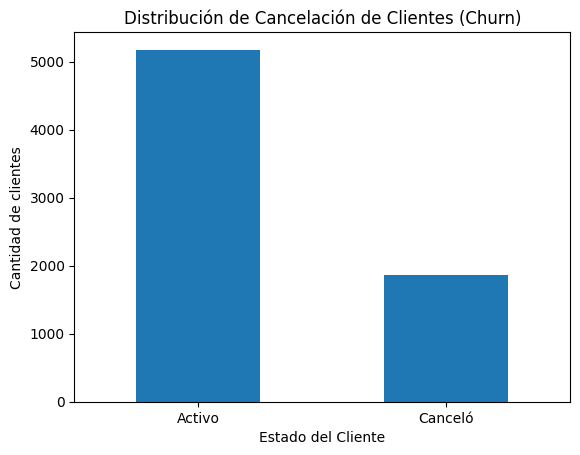

In [16]:
import matplotlib.pyplot as plt

ax = df["Churn"].value_counts().plot(kind="bar")

plt.title("Distribución de Cancelación de Clientes (Churn)")
plt.xlabel("Estado del Cliente")
plt.ylabel("Cantidad de clientes")

ax.set_xticklabels(["Activo", "Canceló"], rotation=0)

plt.show()

##Correlacion y seleccion de variables

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
corr = df.corr()

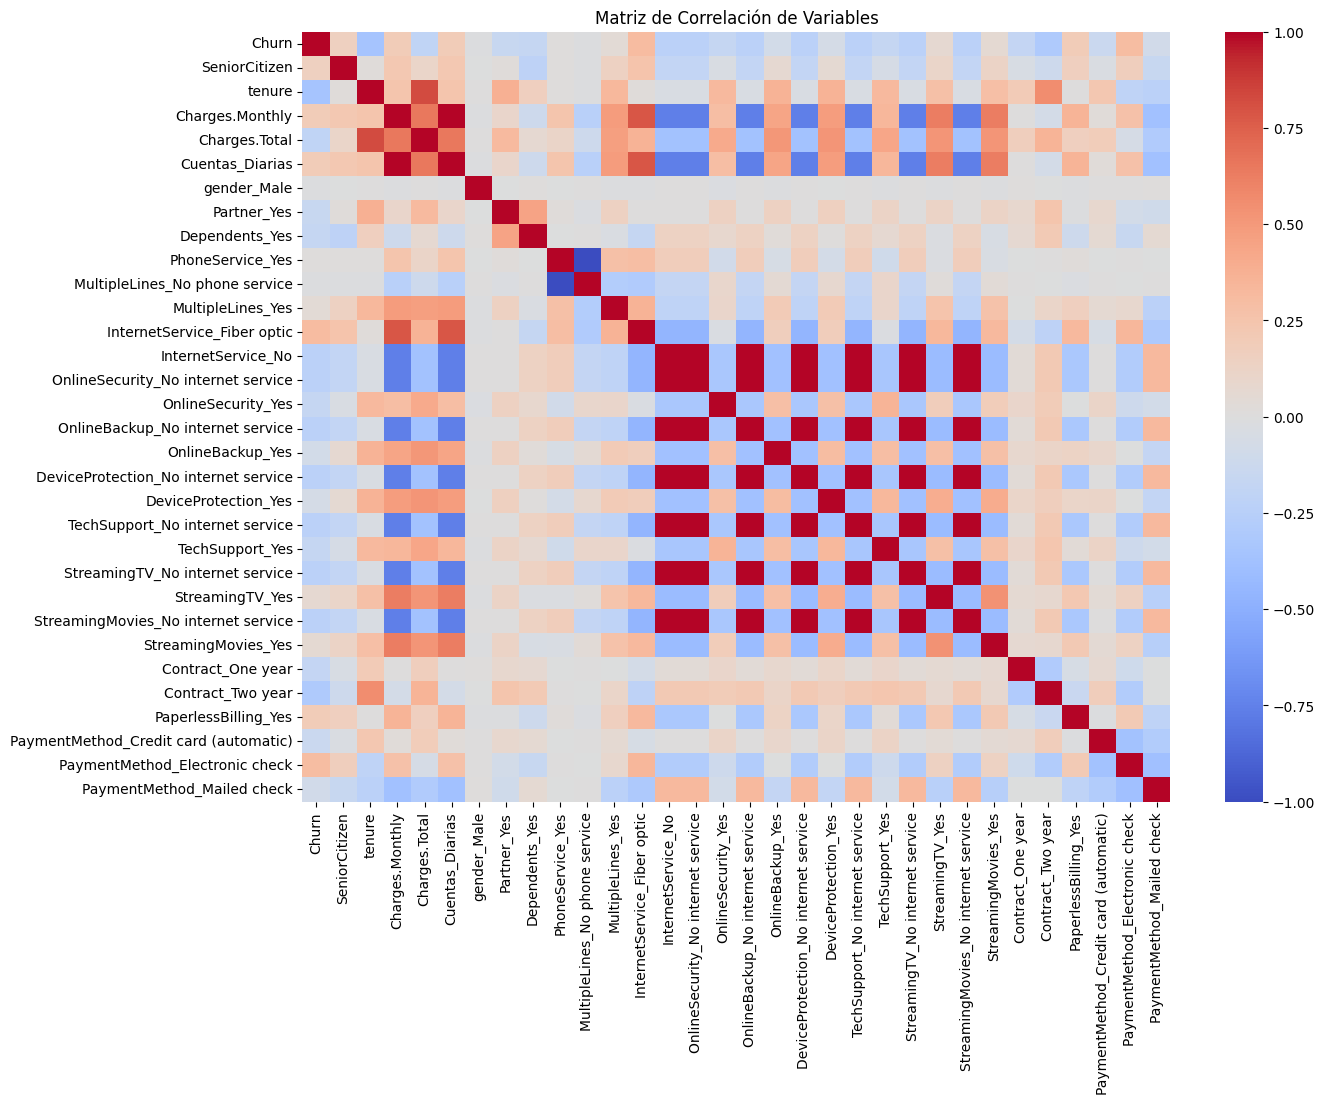

In [19]:
plt.figure(figsize=(14,10))

sns.heatmap(corr, annot=False, cmap="coolwarm")

plt.title("Matriz de Correlación de Variables")

plt.show()

In [20]:
corr["Churn"].sort_values(ascending=False)

,Churn
Churn,1.000000
InternetService_Fiber optic,0.308020
PaymentMethod_Electronic check,0.301919
Charges.Monthly,0.193356
Cuentas_Diarias,0.193356
PaperlessBilling_Yes,0.191825
SeniorCitizen,0.150889
StreamingTV_Yes,0.063228
StreamingMovies_Yes,0.061382
MultipleLines_Yes,0.040102


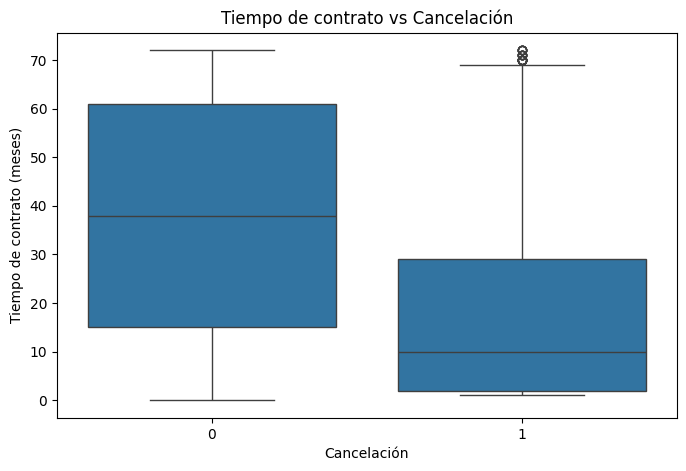

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Churn", y="tenure", data=df)

plt.title("Tiempo de contrato vs Cancelación")
plt.xlabel("Cancelación")
plt.ylabel("Tiempo de contrato (meses)")

plt.show()

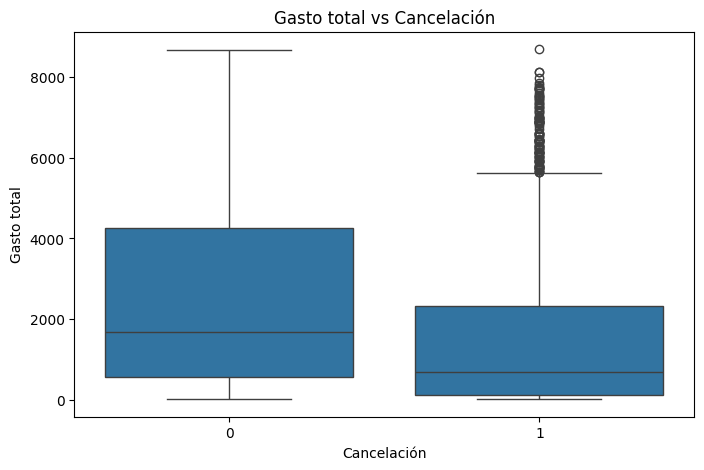

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Churn", y="Charges.Total", data=df)

plt.title("Gasto total vs Cancelación")
plt.xlabel("Cancelación")
plt.ylabel("Gasto total")

plt.show()

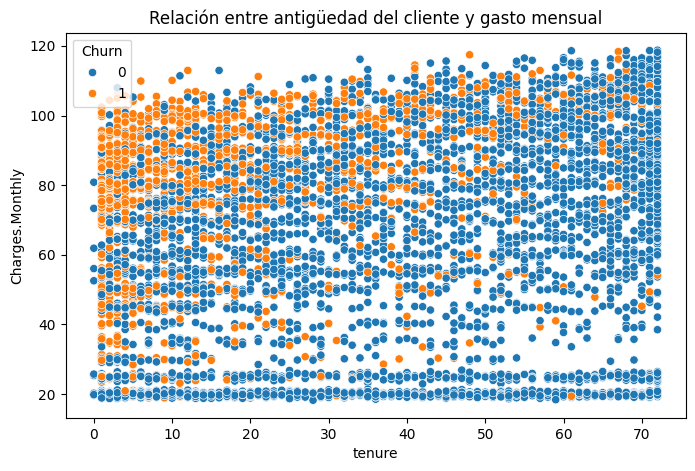

In [23]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="tenure", y="Charges.Monthly", hue="Churn", data=df)

plt.title("Relación entre antigüedad del cliente y gasto mensual")

plt.show()

##Modelado predictivo

In [34]:
df.isna().sum()

,0
Churn,0
SeniorCitizen,0
tenure,0
Charges.Monthly,0
Charges.Total,0
Cuentas_Diarias,0
gender_Male,0
Partner_Yes,0
Dependents_Yes,0
PhoneService_Yes,0


In [35]:
df = df.fillna(df.mean())

In [36]:
df.isna().sum()

,0
Churn,0
SeniorCitizen,0
tenure,0
Charges.Monthly,0
Charges.Total,0
Cuentas_Diarias,0
gender_Male,0
Partner_Yes,0
Dependents_Yes,0
PhoneService_Yes,0


In [37]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [40]:
from sklearn.linear_model import LogisticRegression

modelo_log = LogisticRegression(max_iter=1000)

modelo_log.fit(X_train_scaled, y_train)

y_pred_log = modelo_log.predict(X_test_scaled)

In [41]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_log))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_log))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_log))

Accuracy: 0.8062455642299503

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1036
           1       0.67      0.54      0.59       373

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409


Matriz de confusión:
[[936 100]
 [173 200]]


In [42]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(random_state=42)

modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)

In [43]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_rf))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.7970191625266146

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.47      0.55       373

    accuracy                           0.80      1409
   macro avg       0.75      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409


Matriz de confusión:
[[947  89]
 [197 176]]


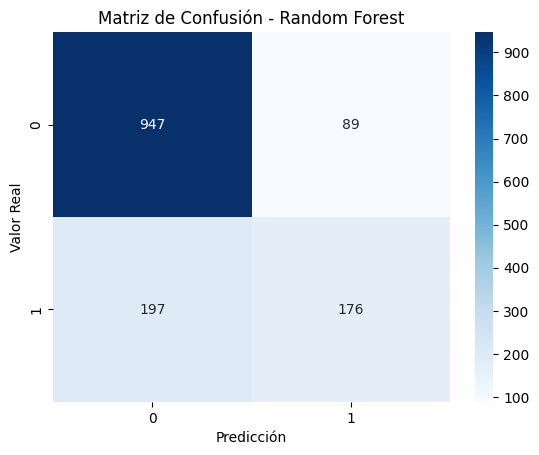

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

##Interpretacion y conclusiones

In [45]:
coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo_log.coef_[0]
})

coeficientes = coeficientes.sort_values(by="Coeficiente", ascending=False)

coeficientes.head(10)

,Variable,Coeficiente
3,Charges.Total,0.652214
11,InternetService_Fiber optic,0.602866
22,StreamingTV_Yes,0.198767
10,MultipleLines_Yes,0.183275
24,StreamingMovies_Yes,0.169376
29,PaymentMethod_Electronic check,0.165504
27,PaperlessBilling_Yes,0.144234
0,SeniorCitizen,0.068416
9,MultipleLines_No phone service,0.046840
18,DeviceProtection_Yes,0.035214


In [46]:
coeficientes.tail(10)

,Variable,Coeficiente
19,TechSupport_No internet service,-0.071222
17,DeviceProtection_No internet service,-0.071222
23,StreamingMovies_No internet service,-0.071222
14,OnlineSecurity_Yes,-0.114047
20,TechSupport_Yes,-0.116999
2,Charges.Monthly,-0.272762
4,Cuentas_Diarias,-0.272762
25,Contract_One year,-0.292889
26,Contract_Two year,-0.650514
1,tenure,-1.395429


In [47]:
importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo_rf.feature_importances_
})

importancias = importancias.sort_values(by="Importancia", ascending=False)

importancias.head(10)

,Variable,Importancia
3,Charges.Total,0.166250
1,tenure,0.157352
4,Cuentas_Diarias,0.129851
2,Charges.Monthly,0.123425
29,PaymentMethod_Electronic check,0.036927
11,InternetService_Fiber optic,0.036556
26,Contract_Two year,0.035396
5,gender_Male,0.024584
27,PaperlessBilling_Yes,0.023805
25,Contract_One year,0.020906


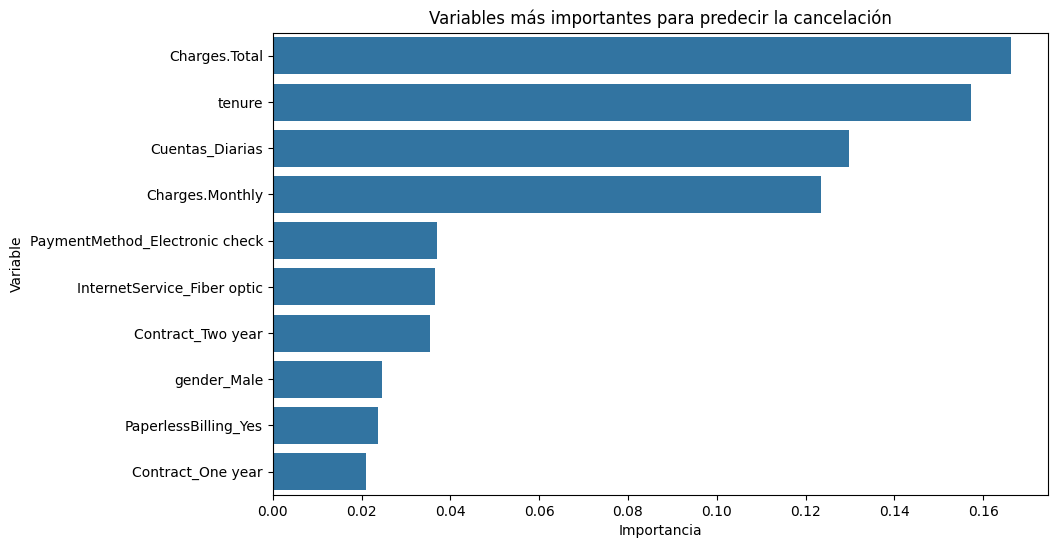

In [48]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importancia",
    y="Variable",
    data=importancias.head(10)
)

plt.title("Variables más importantes para predecir la cancelación")

plt.show()

## Conclusiones

A partir del análisis exploratorio de los datos y la construcción de modelos predictivos, fue posible identificar patrones relevantes asociados a la cancelación de clientes (churn). El estudio permitió comprender mejor qué factores influyen en la decisión de los clientes de abandonar el servicio y evaluar qué modelos de machine learning son más adecuados para predecir este comportamiento.

Durante el proceso de modelado se entrenaron dos modelos diferentes: Regresión Logística y Random Forest. La Regresión Logística requirió la normalización de los datos debido a su sensibilidad a la escala de las variables, mientras que Random Forest no necesitó este paso, ya que se basa en árboles de decisión y no depende de la magnitud de los datos. Tras evaluar ambos modelos utilizando métricas como accuracy, precision, recall, F1-score y la matriz de confusión, se observó que el modelo Random Forest presentó un mejor desempeño general en la predicción de la cancelación de clientes. Esto se debe principalmente a su capacidad para capturar relaciones más complejas entre las variables del dataset.

El análisis de la importancia de las variables mostró que algunos factores tienen un impacto significativo en la probabilidad de cancelación. Entre los más relevantes se encuentran el tiempo de permanencia del cliente (tenure), el tipo de contrato, el gasto mensual y el gasto total acumulado. En general, se observa que los clientes con menor tiempo de permanencia y contratos de corta duración presentan una mayor probabilidad de cancelar el servicio, mientras que aquellos con contratos más largos o mayor antigüedad tienden a permanecer en la empresa.

Estos resultados permiten proponer algunas estrategias orientadas a mejorar la retención de clientes. Por ejemplo, la empresa podría implementar programas de fidelización dirigidos especialmente a los clientes nuevos durante sus primeros meses de servicio, ofrecer incentivos para migrar a contratos de mayor duración o desarrollar campañas de retención específicas para clientes con mayor riesgo de cancelación. Asimismo, el análisis del comportamiento de gasto de los clientes podría ayudar a identificar perfiles con mayor probabilidad de abandono y anticipar acciones preventivas.

En conclusión, el uso de técnicas de análisis de datos y modelos predictivos permite comprender mejor el comportamiento de los clientes y apoyar la toma de decisiones estratégicas dentro de la empresa. La implementación de este tipo de modelos puede contribuir significativamente a reducir la cancelación de clientes y mejorar la planificación de estrategias de retención.
